In [1]:
# ==========================
# NOTEBOOK SETUP
# ==========================

# Import os.
# os helps Python work with folders and file paths.
import os

# Import sys.
# sys lets us modify Python's module search path.
import sys

# Go one folder up from "notebooks".
# This gives us the project root folder.
project_root = os.path.abspath("..")

# Add the project root to Python's search path.
# This allows Python to find the "src" folder.
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
# Import the function that loads data.
from src.load_data import load_data

# Import the inspection functions.
from src.preprocessing import (
    dataset_info,
    missing_values,
    summary_statistics,
    preview_data
)

# load data and summary statistics

In [3]:
df = load_data("../data/titanic.csv")

In [4]:
preview_data(df)

FIRST FIVE ROWS
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  



In [5]:
dataset_info(df)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB



In [6]:
missing_values(df)

MISSING VALUES
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64



In [7]:
summary_statistics(df)

SUMMARY STATISTICS
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200



# preprocessing the data

In [8]:
from src.load_data import load_data

from src.preprocessing import (
    preview_data,
    dataset_info,
    missing_values,
    summary_statistics,
    preprocess_data,
    encode_features,
    prepare_data
)


In [9]:
# Encode categorical columns.
df = encode_features(df)

# Display the first five rows.
preview_data(df)

FIRST FIVE ROWS
   survived  pclass  sex   age  sibsp  parch     fare  embarked  class    who  \
0         0       3    1  22.0      1      0   7.2500       0.0  Third    man   
1         1       1    0  38.0      1      0  71.2833       1.0  First  woman   
2         1       3    0  26.0      0      0   7.9250       0.0  Third  woman   
3         1       1    0  35.0      1      0  53.1000       0.0  First  woman   
4         0       3    1  35.0      0      0   8.0500       0.0  Third    man   

   adult_male deck  embark_town alive  alone  
0        True  NaN  Southampton    no  False  
1       False    C    Cherbourg   yes  False  
2       False  NaN  Southampton   yes   True  
3       False    C  Southampton   yes  False  
4        True  NaN  Southampton    no   True  



In [10]:
df = preprocess_data(df)

In [11]:
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']


In [12]:
df["alone"] = df["alone"].astype(int)

In [13]:
# Prepare features and target.
X, y = prepare_data(df)

In [14]:
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone
0,3,1,22.0,1,0,7.2500,0.0,0
1,1,0,38.0,1,0,71.2833,1.0,0
2,3,0,26.0,0,0,7.9250,0.0,1
3,1,0,35.0,1,0,53.1000,0.0,0
4,3,1,35.0,0,0,8.0500,0.0,1


# model building

In [ ]:
from src.model import (
    split_data,
    train_model,
    predict_model,
    evaluate_model
)

# Import evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


In [15]:
# Split the dataset.
X_train, X_test, y_train, y_test = split_data(X, y)

# Display the shapes.
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (712, 8)
X_test : (179, 8)
y_train: (712,)
y_test : (179,)


In [16]:
# Train the machine learning model.
model = train_model(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [17]:
# Display the trained model.
model

LogisticRegression(max_iter=1000)

# model evaluation

In [19]:
# Make predictions using the test dataset.
predictions = predict_model(model, X_test)

In [21]:
# Evaluate the trained model.
accuracy, cm, report = evaluate_model(y_test, predictions)

In [22]:
# Display the model accuracy.
print("Accuracy:", accuracy)

Accuracy: 0.7988826815642458


In [23]:
# Display the confusion matrix.
print(cm)

[[90 15]
 [21 53]]


In [24]:
# Display the classification report.
print(report)

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



# visualization

In [26]:
from src.visualization import (
    plot_survival,
    plot_age,
    plot_fare,
)

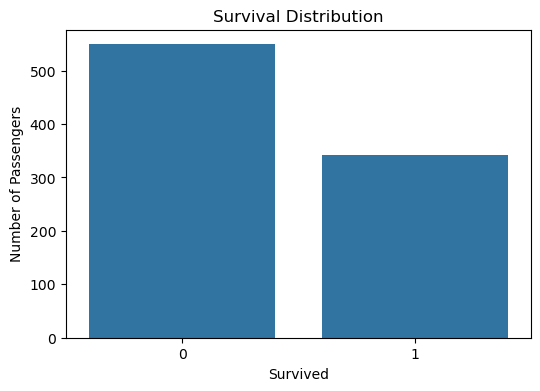

In [27]:
plot_survival(df)

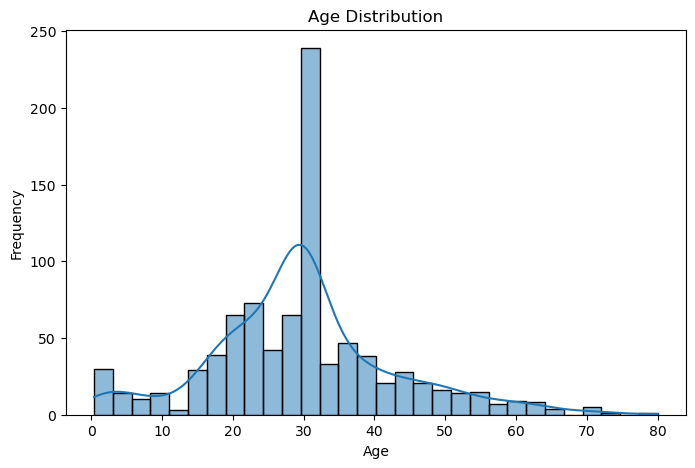

In [28]:
plot_age(df)

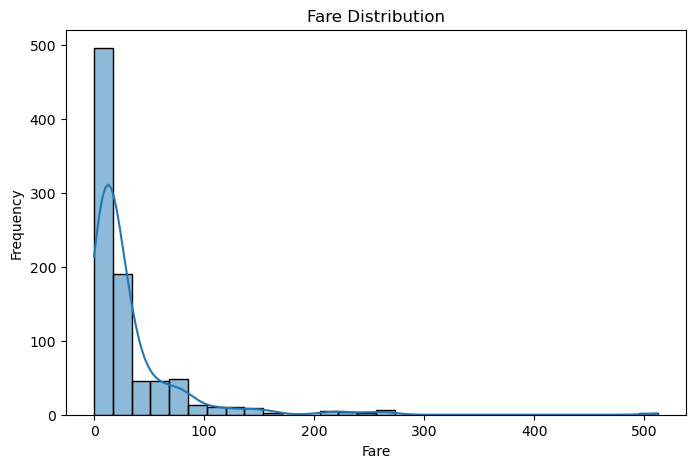

In [29]:
plot_fare(df)

# utils functions

In [31]:
from src.utils import (
    save_model,
    load_model,
    save_dataframe,
)

In [32]:
save_model(model, "../model.joblib")

Model saved to: ../model.joblib


In [33]:
loaded_model = load_model("../model.joblib")

loaded_model

LogisticRegression(max_iter=1000)

In [34]:
loaded_model.predict(X_test[:5])

array([0, 0, 0, 1, 1])

In [35]:
save_dataframe(df, "../clean_titanic.csv")

Data saved to: ../clean_titanic.csv
